Shapes: 
  races       : (1125, 18) 
  results     : (26759, 18) 
  pitstops    : (11371, 7) 
  laptimes    : (589081, 6) 
  circuits    : (77, 9) 
  drivers     : (861, 9) 
  constructors: (212, 5)
Train shape: (442410, 19) Test shape: (112828, 19)

Training Random Forest...
Done.
OOB score (R^2): 0.9775

=== TEST METRICS ===
MAE  : 1482.7 ms  (1.483 s)
RMSE : 16061.4 ms  (16.061 s)

Sample of best-predicted laps:
 raceId  driverId  lap  true_ms       pred_ms  abs_err_ms
   1118       832    9  76623.0  76622.997470    0.002530
     34        18   25  99446.0  99446.003214    0.003214
    959       815   11  81946.0  81945.994121    0.005879
   1140       822   63  81629.0  81628.981091    0.018909
   1093       815   45 100310.0 100309.970131    0.029869
    141        31   29  90993.0  90992.969714    0.030286
    178        14   16  83921.0  83921.032000    0.032000
   1023       825   14  86562.0  86561.967613    0.032387
    209        35   49  88500.0  88500.039835    0.039835
 

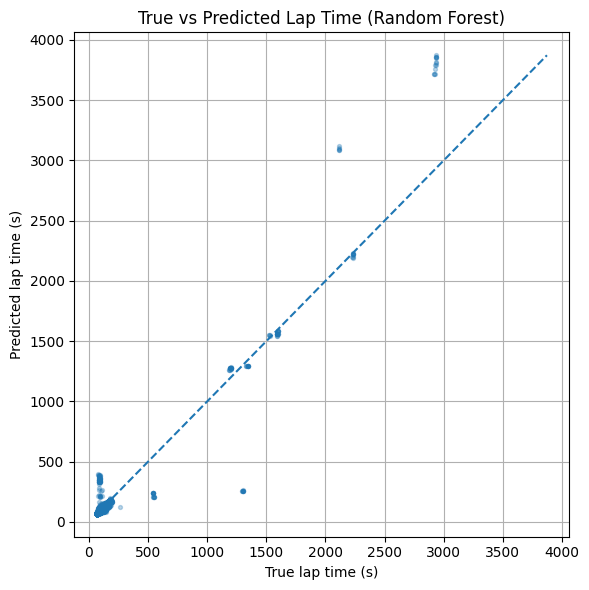

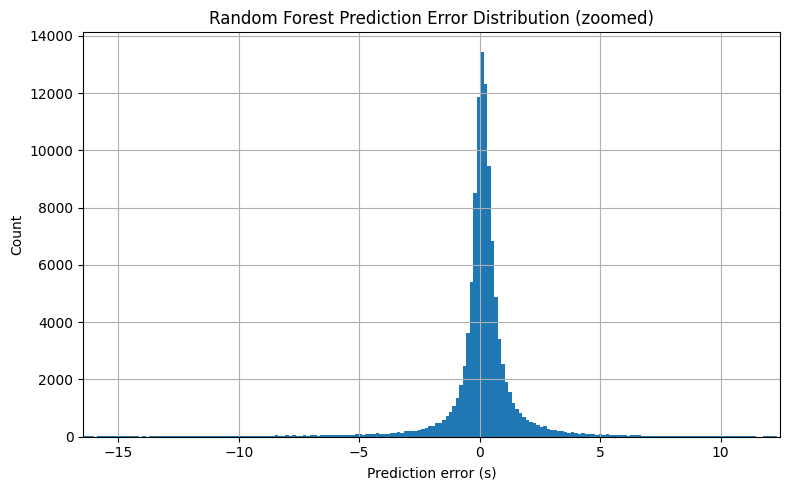


Top 20 feature importances:
           feature  importance
        lap_med_ms    0.854339
          roll3_ms    0.042923
       prev_lap_ms    0.028390
               lng    0.022455
              year    0.018640
               lap    0.012155
               alt    0.011587
    circuit_id_enc    0.002973
        pos_change    0.002069
              grid    0.001110
     driver_id_enc    0.000851
    laps_since_pit    0.000515
          prev_pos    0.000496
       race_med_ms    0.000494
      lap_position    0.000489
constructor_id_enc    0.000238
               lat    0.000169
             round    0.000108
          pit_flag    0.000000


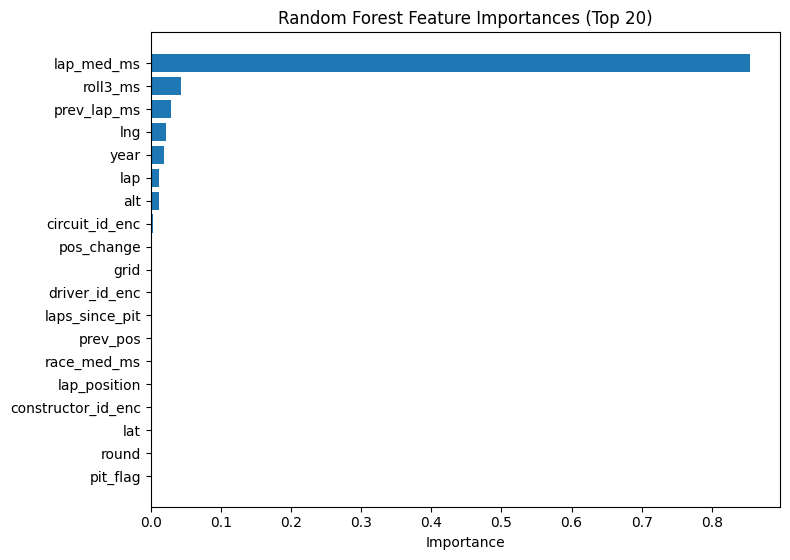

In [4]:
# ============================================
# F1 Lap Time Prediction — Random Forest
# Predicts absolute lap time (ms) on non-pit laps
# Same feature logic as NN version (time-series, medians, etc.)
# ============================================

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# -----------------------------
# 1) Load CSVs
# -----------------------------
races        = pd.read_csv("races.csv")
results      = pd.read_csv("results.csv")
pitstops     = pd.read_csv("pit_stops.csv")
laptimes     = pd.read_csv("lap_times.csv")
circuits     = pd.read_csv("circuits.csv")
constructors = pd.read_csv("constructors.csv")
drivers      = pd.read_csv("drivers.csv")

print("Shapes:",
      "\n  races       :", races.shape,
      "\n  results     :", results.shape,
      "\n  pitstops    :", pitstops.shape,
      "\n  laptimes    :", laptimes.shape,
      "\n  circuits    :", circuits.shape,
      "\n  drivers     :", drivers.shape,
      "\n  constructors:", constructors.shape)

# -----------------------------
# 2) Basic checks & typing
# -----------------------------
for col in ["raceId", "driverId", "lap", "milliseconds", "position"]:
    if col not in laptimes.columns:
        raise ValueError(f"Expected column '{col}' in lap_times.csv")

# numeric dtype for lap times
laptimes["milliseconds"] = pd.to_numeric(laptimes["milliseconds"], errors="coerce")

# rename to avoid collision with results.position
laptimes = laptimes.rename(columns={"position": "lap_position"})
results  = results.rename(columns={"position": "finish_position"})

# keep one row per (raceId, driverId) in results
if "positionOrder" in results.columns:
    results = results.sort_values(
        ["raceId", "driverId", "positionOrder"], na_position="last"
    )
results = results.drop_duplicates(subset=["raceId", "driverId"], keep="first")

# build simple pit-flag map
if not pitstops.empty and "lap" in pitstops.columns:
    pit = pitstops.copy()
    pit["pit_flag"] = 1
    pit_map = pit[["raceId", "driverId", "lap", "pit_flag"]].drop_duplicates(
        ["raceId", "driverId", "lap"]
    )
else:
    pit_map = pd.DataFrame(columns=["raceId", "driverId", "lap", "pit_flag"])

# -----------------------------
# 3) Build base table
# -----------------------------
df = (
    laptimes
    .merge(
        races[["raceId", "year", "round", "circuitId"]],
        on="raceId", how="left"
    )
    .merge(
        circuits[["circuitId", "name", "lat", "lng", "alt"]],
        on="circuitId", how="left"
    )
    .merge(
        results[[
            "raceId", "driverId", "constructorId",
            "grid", "finish_position", "points"
        ]],
        on=["raceId", "driverId"], how="left"
    )
    .merge(
        drivers[["driverId", "surname"]],
        on="driverId", how="left"
    )
)

if not pit_map.empty:
    df = df.merge(pit_map, on=["raceId", "driverId", "lap"], how="left")

df["pit_flag"] = df["pit_flag"].fillna(0).astype(int)

# sort once for time-series features
df = df.sort_values(["raceId", "driverId", "lap"]).reset_index(drop=True)

# -----------------------------
# 4) Time-series features
# -----------------------------
grp = df.groupby(["raceId", "driverId"], sort=False)

# previous lap & 3-lap rolling mean (exclude current)
df["prev_lap_ms"] = grp["milliseconds"].shift(1)
df["roll3_ms"]    = grp["milliseconds"].transform(
    lambda s: s.shift(1).rolling(3, min_periods=1).mean()
)

# laps since last pit within each continuous stint
df["segment"] = grp["pit_flag"].cumsum()
df["laps_since_pit"] = df.groupby(["raceId", "driverId", "segment"]).cumcount()
df.drop(columns=["segment"], inplace=True)

# drop laps with no previous lap time
df = df[~df["prev_lap_ms"].isna()].copy()

# -----------------------------
# 5) Filter to non-pit laps + de-outlier
# -----------------------------
# restrict to non-pit laps only
df = df[df["pit_flag"] == 0].copy()

# simple race-wise outlier trimming (1%–99%)
g = df.groupby("raceId")["milliseconds"]
low  = g.transform(lambda s: s.quantile(0.01))
high = g.transform(lambda s: s.quantile(0.99))
df = df[(df["milliseconds"] >= low) & (df["milliseconds"] <= high)].copy()

# recompute groupby after filtering
grp = df.groupby(["raceId", "driverId"], sort=False)

# -----------------------------
# 6) Additional race/lap context
# -----------------------------
df["race_med_ms"] = df.groupby("raceId")["milliseconds"].transform("median")
df["lap_med_ms"]  = df.groupby(["raceId", "lap"])["milliseconds"].transform("median")

df["prev_pos"]   = grp["lap_position"].shift(1)
df["pos_change"] = df["prev_pos"].fillna(df["lap_position"]) - df["lap_position"]

# -----------------------------
# 7) Feature columns (no explicit baseline_ms here)
# -----------------------------
numeric_cols = [
    "year", "round", "lap", "grid",
    "prev_lap_ms", "roll3_ms",
    "pit_flag", "laps_since_pit",
    "lat", "lng", "alt",
    "race_med_ms", "lap_med_ms",
    "lap_position", "prev_pos", "pos_change",
    # could add baseline_ms if you wanted a stronger built-in baseline
]

cat_cols = ["driverId", "constructorId", "circuitId"]

# ensure numeric cols exist and fill NaNs with column median
for c in numeric_cols:
    if c not in df.columns:
        df[c] = np.nan

df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].median(numeric_only=True)
)

# -----------------------------
# 8) Encode categoricals as integer IDs
# -----------------------------
def build_id_map(series):
    uniq = pd.Series(series.dropna().unique())
    if np.issubdtype(uniq.dtype, np.number):
        uniq = uniq.astype(int)
    return {int(v): i + 1 for i, v in enumerate(sorted(uniq))}  # 0 = UNKNOWN

driver_map  = build_id_map(df["driverId"])
cons_map    = build_id_map(df["constructorId"])
circuit_map = build_id_map(df["circuitId"])

def map_with_unk(series, mp):
    return series.apply(lambda v: mp.get(int(v), 0)).astype("int64")

X_driver = map_with_unk(df["driverId"],      driver_map).to_numpy()
X_cons   = map_with_unk(df["constructorId"], cons_map).to_numpy()
X_circ   = map_with_unk(df["circuitId"],     circuit_map).to_numpy()

X_num = df[numeric_cols].astype("float32").values
y     = df["milliseconds"].astype("float32").values

# -----------------------------
# 9) Grouped train/test split (by raceId)
#     + scale numerics on TRAIN ONLY (fixes leakage)
# -----------------------------
groups = df["raceId"].values
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_num, groups=groups))

# scale numeric features
scaler = StandardScaler()
X_num_tr = scaler.fit_transform(X_num[train_idx])
X_num_te = scaler.transform(X_num[test_idx])

# concatenate scaled numerics + categorical indices
def build_full_matrix(idx, X_num_scaled):
    return np.concatenate(
        [
            X_num_scaled,
            X_driver[idx].reshape(-1, 1),
            X_cons[idx].reshape(-1, 1),
            X_circ[idx].reshape(-1, 1),
        ],
        axis=1,
    )

X_tr = build_full_matrix(train_idx, X_num_tr)
X_te = build_full_matrix(test_idx, X_num_te)

y_tr = y[train_idx]
y_te = y[test_idx]

print("Train shape:", X_tr.shape, "Test shape:", X_te.shape)

# -----------------------------
# 10) Random Forest model
# -----------------------------
rf = RandomForestRegressor(
    n_estimators=200,        # a bit larger than 100, still manageable
    max_depth=None,          # allow deep trees
    min_samples_split=4,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42,
    oob_score=True,
)

print("\nTraining Random Forest...")
rf.fit(X_tr, y_tr)
print("Done.")
print(f"OOB score (R^2): {rf.oob_score_:.4f}")

# -----------------------------
# 11) Metrics on test set
# -----------------------------
y_pred = rf.predict(X_te)

def rmse(a, b):
    return math.sqrt(np.mean((a - b) ** 2))

mae_ms  = mean_absolute_error(y_te, y_pred)
rmse_ms = rmse(y_te, y_pred)

print("\n=== TEST METRICS ===")
print(f"MAE  : {mae_ms:.1f} ms  ({mae_ms/1000.0:.3f} s)")
print(f"RMSE : {rmse_ms:.1f} ms  ({rmse_ms/1000.0:.3f} s)")

# attach predictions to a test DataFrame for inspection
test_df = df.iloc[test_idx].copy()
test_df["true_ms"]   = y_te
test_df["pred_ms"]   = y_pred
test_df["abs_err_ms"] = np.abs(y_pred - y_te)

# show a few laps with smallest / largest errors
print("\nSample of best-predicted laps:")
print(
    test_df[["raceId", "driverId", "lap", "true_ms", "pred_ms", "abs_err_ms"]]
    .sort_values("abs_err_ms")
    .head(10)
    .to_string(index=False)
)

print("\nSample of worst-predicted laps:")
print(
    test_df[["raceId", "driverId", "lap", "true_ms", "pred_ms", "abs_err_ms"]]
    .sort_values("abs_err_ms", ascending=False)
    .head(10)
    .to_string(index=False)
)

# -----------------------------
# 12) Plots
# -----------------------------

# 12.1) True vs Predicted lap time (seconds)
true_sec = y_te / 1000.0
pred_sec = y_pred / 1000.0

plt.figure(figsize=(6, 6))
plt.scatter(true_sec, pred_sec, alpha=0.3, s=8)

min_t = min(true_sec.min(), pred_sec.min())
max_t = max(true_sec.max(), pred_sec.max())
plt.plot([min_t, max_t], [min_t, max_t], linestyle="--")

plt.xlabel("True lap time (s)")
plt.ylabel("Predicted lap time (s)")
plt.title("True vs Predicted Lap Time (Random Forest)")
plt.grid(True)
plt.tight_layout()
plt.show()

# 12.2) Error distribution (seconds) with zoomed x-axis
errors_ms = y_pred - y_te
errors_s  = errors_ms / 1000.0

err_lo, err_hi = np.percentile(errors_s, [0.5, 99.5])

plt.figure(figsize=(8, 5))
plt.hist(errors_s, bins=200, range=(err_lo, err_hi))
plt.xlabel("Prediction error (s)")
plt.ylabel("Count")
plt.title("Random Forest Prediction Error Distribution (zoomed)")
plt.xlim(err_lo, err_hi)
plt.grid(True)
plt.tight_layout()
plt.show()

# 12.3) Feature importance
feat_names = (
    numeric_cols
    + ["driver_id_enc", "constructor_id_enc", "circuit_id_enc"]
)
importances = rf.feature_importances_

imp_df = (
    pd.DataFrame({"feature": feat_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("\nTop 20 feature importances:")
print(imp_df.head(20).to_string(index=False))

plt.figure(figsize=(8, max(4, 0.3 * len(imp_df.head(20)))))
plt.barh(imp_df["feature"].head(20)[::-1],
         imp_df["importance"].head(20)[::-1])
plt.xlabel("Importance")
plt.title("Random Forest Feature Importances (Top 20)")
plt.tight_layout()
plt.show()
